<h2 style="font-family: 'Courier New';">
CAPSTONE - U.S STOCKS AND RETURNS
</h2>

**Capstone Project - U.S. Stock Market Analysisand Modeling**

Data source: [Stooq.com](https://stooq.com/t/?i=518&v=1) - a publicly accessible financial data platform covering U.S. listed stocks, scraped for   non-commercial purposes.

The dataset was scraped from Stooq.com (Index 518 - U.S. Stocks) and covers approximately 20,000+ publicly listed U.S. stocks across 3 separate data views.
It includes daily price data (Open, High, Low, Last closing price), trading Volume and Turnover, short to long-term return percentages (1D, 3D, 5D, 10D, 1M, 2M, 3M, 6M, YTD), and 52-week price metrics (52W Change, 1Y High, 1Y Low).

The goal of this project is to clean, segment, and analyze this data to understand stock behavior across liquidity, price, and return dimensions and then apply a machine learning algorithm to perform clustering,regression or classification.

Stooq does not prohibit non-commercial scraping in its `robots.txt` or Terms of Service, and all pages used are publicly accessible without login or authentication.


---

<h2 style="font-family: 'Courier New';">
Imports
</h2>

In [63]:
import time, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# selenium and beautifulsoup imports

from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC, color

# sklearn imports

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder, FunctionTransformer, RobustScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Evaluation Imports

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score



---

<h2 style="font-family: 'Courier New';">
Data Cleaning & Preprocessing
</h2>

This section covers all data preparation steps needed before analysis and modeling.  
We handle merging the 3 scraped files, fixing column data types, cleaning percentage/suffix formats, and handling missing or corrupted values.
- **Task 1.1** — Merge the 3 CSVs into one dataset using a left join on `Symbol`
- **Task 1.2** — Normalize column names and convert string-encoded numbers to correct data types
- **Task 1.3** — Handle nulls, empty columns, duplicates, and fill missing values


<h4>
Task 1.1 - Combine all the separated files as the dataset is divided into 3 files ( stooq_view1.csv , stooq_view4.csv , stooq_view1.csv )
</h4>

**Process:** Load all 3 CSVs using `pd.read_csv()` and merge them on the `Symbol` column using `merge()` to perform a **left join**.
A left merge ensures we only keep stocks present in `view1` and fill in return/52W data where available - rows with no match get `NaN` which are removed later.


In [68]:
ds_1=pd.read_csv('stooq_view1.csv')
ds_2=pd.read_csv('stooq_view4.csv')
ds_3=pd.read_csv('stooq_view6.csv')

In [69]:
common_col=set(ds_1['Symbol']) & set(ds_2['Symbol']) & set(ds_3['Symbol'])
ds_1=ds_1.merge(
    ds_2[['Symbol','1D','3D','5D','10D','1M','2M','3M','6M','YTD']],
    on='Symbol',
    how='left'
)
ds=ds_1.merge(
    ds_3[['Symbol','52W Change','1Y High','1Y Low']],
    on='Symbol',
    how='left'
)


In [ ]:
ds

<h4>
Task 1.2 - Format and normalize column names and their data types
</h4>

**Process:** Inspect column dtypes to identify columns stored as strings that should be numeric.  
Return columns contain `%` and `+` characters that must be stripped before type conversion.


In [70]:
ds.dtypes

Symbol            str
Name              str
Open          float64
High          float64
Low           float64
Last          float64
Change            str
Volume            str
Turnover          str
Date              str
Col10         float64
1D                str
3D                str
5D                str
10D               str
1M                str
2M                str
3M                str
6M                str
YTD               str
52W Change        str
1Y High       float64
1Y Low        float64
dtype: object

In [71]:
ds[['1D', '3D', '5D', '10D', '1M', '2M', '3M', '6M','YTD', '52W Change','Change','Volume','Turnover']]

,1D,3D,5D,10D,1M,2M,3M,6M,YTD,52W Change,Change,Volume,Turnover
0,+2.20%,-2.70%,-1.92%,-8.17%,+13.3%,+5.04%,+14.0%,-7.19%,-6.62%,+9.99%,+2.20%,4.33m,346m
1,-3.82%,-7.47%,-13.93%,-23.90%,-5.14%,-10.76%,-7.57%,+23.2%,+11.7%,+109.42%,-3.82%,6.95m,314m
2,NaN,NaN,+0.10%,+0.31%,+0.42%,+0.42%,+0.42%,+0.42%,+0.42%,+0.42%,NaN,NaN,NaN
3,-1.49%,+1.54%,-6.71%,-11.41%,-3.86%,-5.04%,-12.87%,-14.12%,-14.12%,-14.12%,-1.49%,6.02m,77.2k
4,0.00%,NaN,0.00%,0.00%,0.00%,-33.33%,-6.98%,-33.33%,-33.33%,-33.33%,0.00%,47.5k,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,+2.74%,+1.62%,+0.27%,-0.27%,+13.8%,-6.94%,-11.54%,-26.59%,-27.02%,+21.52%,+2.74%,462k,2.84m
5996,NaN,NaN,NaN,NaN,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,NaN,NaN,NaN
5997,+1.32%,-0.83%,-2.34%,+1.69%,+10.0%,-2.06%,+14.9%,+28.1%,+28.9%,+62.93%,+1.32%,494k,10.8m
5998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Issues found:**
- Return and change columns (e.g. `1D`, `YTD`) are stored as `string` data type due to `%` and `+` formatting they must be stripped and cast to `float`
- Percentage columns will be renamed with a `_per` suffix (e.g. `1D` to `1D_return_per`) to preserve the meaning of the data
- `Volume` and `Turnover` use shorthand suffixes (`k` = thousand, `m` = million, `g` = billion) that need to be expanded to raw numeric values


In [72]:
# We will replace all the "%" suffix and "+" prefix

cols = ['1D', '3D', '5D', '10D', '1M', '2M', '3M', '6M', 'YTD', '52W Change','Change']

ds[cols] = ds[cols].replace(r'[%+\s]', '', regex=True)
ds[cols] = ds[cols].replace(r'^\-$', np.nan, regex=True)
ds[cols] = ds[cols].replace(r'k', '', regex=True)
ds[cols] = ds[cols].replace('', np.nan)


In [107]:
# Now we need to replace the column names

ds=ds.rename(columns={
    'Change':'Change_per',
    '1D':'1D_return_per',
    '3D':'3D_return_per',
    '5D':'5D_return_per',
    '10D':'10D_return_per',
    '1M':'1M_return_per',
    '2M':'2M_return_per',
    '3M':'3M_return_per',
    '6M':'6M_return_per',
    'YTD':'YTD_return_per',
    '52W Change':'52W_Change_Per'
})


In [74]:
ds[['1D_return_per', '3D_return_per', '5D_return_per','10D_return_per', '1M_return_per', '2M_return_per', '3M_return_per','6M_return_per', 'YTD_return_per', '52W_Change_Per','Change_per']]

,1D_return_per,3D_return_per,5D_return_per,10D_return_per,1M_return_per,2M_return_per,3M_return_per,6M_return_per,YTD_return_per,52W_Change_Per,Change_per
0,2.20,-2.70,-1.92,-8.17,13.3,5.04,14.0,-7.19,-6.62,9.99,2.20
1,-3.82,-7.47,-13.93,-23.90,-5.14,-10.76,-7.57,23.2,11.7,109.42,-3.82
2,NaN,NaN,0.10,0.31,0.42,0.42,0.42,0.42,0.42,0.42,NaN
3,-1.49,1.54,-6.71,-11.41,-3.86,-5.04,-12.87,-14.12,-14.12,-14.12,-1.49
4,0.00,NaN,0.00,0.00,0.00,-33.33,-6.98,-33.33,-33.33,-33.33,0.00
...,...,...,...,...,...,...,...,...,...,...,...
5995,2.74,1.62,0.27,-0.27,13.8,-6.94,-11.54,-26.59,-27.02,21.52,2.74
5996,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,NaN
5997,1.32,-0.83,-2.34,1.69,10.0,-2.06,14.9,28.1,28.9,62.93,1.32
5998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
# now we can convert the data type of the columns

cols = ['Change_per','1D_return_per', '3D_return_per', '5D_return_per','10D_return_per', '1M_return_per', '2M_return_per', '3M_return_per','6M_return_per', 'YTD_return_per', '52W_Change_Per']

ds[cols] = ds[cols].astype(float)


In [76]:
# Now we will handle "Turnover" and "Volume" columns using map_suffix function that replace and multiply the value according to the suffix

def map_suffix(x):
    if pd.isna(x) or str(x).strip() == '':
        return np.nan

    x = str(x).strip().lower()
    mult = {
        'k': 1e3,
        'm': 1e6,
        'g': 1e9
    }

    if x[-1] in mult:
        return float(x[:-1]) * mult[x[-1]]

    return float(x)

ds['Turnover'] = ds['Turnover'].apply(map_suffix)
ds['Volume'] = ds['Volume'].apply(map_suffix)


<h4>
Task 1.3 - handle the missing values, empty columns, duplicated rows and corrupted data by replacing or removing it
</h4>

In [77]:
ds.isnull().sum()

Symbol               0
Name                 0
Open               385
High               385
Low                385
Last               385
Change_per        1887
Volume            1927
Turnover          3845
Date               385
Col10             6000
1D_return_per     1506
3D_return_per     1688
5D_return_per     1320
10D_return_per    1151
1M_return_per      923
2M_return_per      915
3M_return_per      907
6M_return_per      906
YTD_return_per     906
52W_Change_Per     501
1Y High            501
1Y Low            6000
dtype: int64

**Issues identified:**
- `Unnamed: 10` is a completely empty column and it will be dropped
- Rows where both `Volume` and `Turnover` are null carry no trading data and will be removed to preserve row count
- Missing `Turnover` values will be estimated using the formula: `Turnover = Volume × Average Price`
- Remaining nulls in return columns will be filled with `0` indicating no data was available for that time period


In [79]:
# we will drop all empty columns as it only contains empty values

ds=ds.drop(['Col10','1Y Low'],axis=1)


In [80]:
# in order to preserve rows we will remove empty row based on Turnover and Volume column as removing all the row with a single empty entry can hamper our data

ds=ds[(ds['Turnover'].notna())| (ds['Volume'].notna())]


After removing completely empty rows, we now fill in the remaining missing values using calculated estimates and zero-fill for unavailable periods.


In [ ]:
ds.isnull().sum()

In [82]:
# We will start by filling Turnover Column which contains the most null values in order to do that we will use Formula to calculate Turnover which is `Turnover=Volume×Price`
ds['Turnover'] = ds['Turnover'].fillna(
    ds['Volume'] *
    ((ds['Open'] + ds['High'] + ds['Low'] + ds['Last']) / 4)
)

In [83]:
# We will replace remaining null values with "0"

ds=ds.fillna(0)

---

<h2
style = "font-family: 'Courier New';">
Segmentation & Feature Engineering
</h2>

This section creates multi-dimensional stock segments using `pd.cut()` and adds engineered features for use in the clustering model.  
Segmentations are based on trading volume (liquidity), historical return patterns, 52-week price change, and current price tier.
- **Task 2.1** - We will create 6 segmentation columns using defined rubrics
- **Task 2.2** - Apply log transformation to skewed Volume and Turnover column


<h4>
Task 2.1 - Create Segmentations using various rubrics
</h4>

We created **6 segmentation columns** to classify each stock across different dimensions:
- `Liquidity_Tier` — based on daily trading Volume
- `Total_Return_Performance_Trend` — based on how many return periods (out of 9) were positive
- `52W_Performance` — based on the 52-week price change percentage
- `Short_Term_Segment` — based on the average of short-term return columns (1D–1M)
- `Long_Term_Segment` — based on the average of long-term return columns (2M–YTD)
- `Price_Tier` — based on the last closing price of the stock


**Liquidity Tier** — classifies stocks by daily trading Volume into 5 tiers, indicating how actively a stock is being traded in the market.
| Tier | Volume Range |
|---|---|
| Highly Liquid | > 1M |
| Liquid | 250K – 1M |
| Moderate | 50K – 250K |
| Less Liquid | 10K – 50K |
| Very Less Liquid | < 10K |


In [85]:
ds['Liquidity_Tier'] = pd.cut(
    ds['Volume'],
    bins=[-np.inf, 10000, 50000, 250000, 1000000, np.inf],
    labels=[
        'Very Less Liquid',
        'Less Liquid',
        'Moderate',
        'Liquid',
        'Highly Liquid'
    ]
)

**Total Performance Trend** — counts how many of the 9 return columns (1D to YTD) had a positive value, then assigns a trend label.  
This gives a simple overview of whether a stock has been consistently gaining or losing across multiple timeframes.
| Score | Label |
|---|---|
| 0–1 | Strong Negative Trend |
| 2–3 | Moderate Negative Trend |
| 4–5 | Mixed Trend |
| 6–7 | Moderate Positive Trend |
| 8–9 | Strong Positive Trend |


In [106]:
return_cols = [ '1D_return_per', '3D_return_per', '5D_return_per','10D_return_per', '1M_return_per', '2M_return_per', '3M_return_per','6M_return_per', 'YTD_return_per']

score = (ds[return_cols] > 0).sum(axis=1)

ds['Total_Return_Performance_Trend'] = pd.cut(
    score,
    bins=[-1,1,3,5,7,9],
    labels=[
        'Strong Negative Trend',
        'Moderate Negative Trend',
        'Mixed Trend',
        'Moderate Positive Trend',
        'Strong Positive Trend'
    ]
)

**52-Week Performance** — segments stocks based on their `52W Change` column, which measures price growth or decline over the past year.  
This helps identify extreme performers and crashed stocks in the universe.
| Label | 52W Change Range |
|---|---|
| Crashed | < -50% |
| Underperformer | -50% to -17% |
| Neutral | -17% to +17% |
| Outperformer | +17% to +100% |
| High Flyer | > +100% |


In [87]:
ds['52W_Performance'] = pd.cut(
    ds['52W_Change_Per'],
    bins=[-np.inf, -50, -17, 17, 100, np.inf],
    labels=[
        'Crashed',
        'Underperformer',
        'Neutral',
        'Outperformer',
        'High Flyer'
    ]
)

**Short-Term Return Segment** — takes the average of the 1D, 3D, 5D, 10D, and 1M return columns to see short-term return performance.
| Label | Average Return Range |
|---|---|
| Strong Decline | < -10% |
| Moderate Decline | -10% to -2% |
| Stable | -2% to 2% |
| Moderate Growth | 2% to 10% |
| Strong Growth | > 10% |


In [105]:
short_term = ['1D_return_per', '3D_return_per', '5D_return_per','10D_return_per', '1M_return_per']

ds['Short_Term_Return'] = ds[short_term].mean(axis=1)

ds['Short_Term_Segment'] = pd.cut(
    ds['Short_Term_Return'],
    bins=[-np.inf,-10,-2,2,10,np.inf],
    labels=[
        'Strong Decline',
        'Moderate Decline',
        'Stable',
        'Moderate Growth',
        'Strong Growth'
    ]
)

**Long-Term Return Segment** — takes the average of the 2M, 3M, 6M, YTD, and 52W Change columns to capture return performance over longer periods.
| Label | Average Return Range |
|---|---|
| Strong Decline | < -30% |
| Moderate Decline | -30% to -10% |
| Stable | -10% to 10% |
| Moderate Growth | 10% to 50% |
| Strong Growth | > 50% |


In [104]:
long_term = ['2M_return_per', '3M_return_per','6M_return_per', 'YTD_return_per','52W_Change_Per']

ds['Long_Term_Return'] = ds[long_term].mean(axis=1)

ds['Long_Term_Segment'] = pd.cut(
    ds['Long_Term_Return'],
    bins=[-np.inf,-30,-10,10,50,np.inf],
    labels=[
        'Strong Decline',
        'Moderate Decline',
        'Stable',
        'Moderate Growth',
        'Strong Growth'
    ]
)

**Price Tier** — classifies stocks by their last recorded closing price (`Last` column), a way to distinguish between penny stocks and blue-chip companies.
| Tier | Price Range |
|---|---|
| Penny Stock | < 1 |
| Low-Priced | 1 – 5 |
| Mid-Priced | 5 – 50 |
| High-Priced | 50 – 200 |
| Blue Chip | > 200 |


In [103]:
ds['Price_Tier'] = pd.cut(
    ds['Last'],
    bins=[-np.inf, 1, 5, 50, 200, np.inf],
    labels=[
        'Penny Stock',
        'Low-Priced',
        'Mid-Priced',
        'High-Priced',
        'Blue Chip'
    ]
)

<h4>
Task 2.2 - Feature Engineering
</h4>

**Feature Engineering:** Volume and Turnover are highly right-skewed due to the wide range between small and large-cap stocks.  
We apply `np.log1p()` to create `Volume_Log` and `Turnover_Log` - these log-transformed columns can be used to reduce the effect of extreme outliers.


In [91]:
ds['Volume_Log']=np.log1p(ds['Volume'])
ds['Turnover_Log']=np.log1p(ds['Turnover'])

---

<h2
style = "font-family: 'Courier New';">
Exploratory Data Analysis & Visualization
</h2>

In this section we explore the data visually to understand distributions, spot patterns, and validate our segmentations before feeding data into the model.  
We start with a correlation heatmap, then visualize each segmentation's distribution.


#### Correlation Heatmap
Checking for linear relationships between all numeric features to analyze and perform feature selection for model.


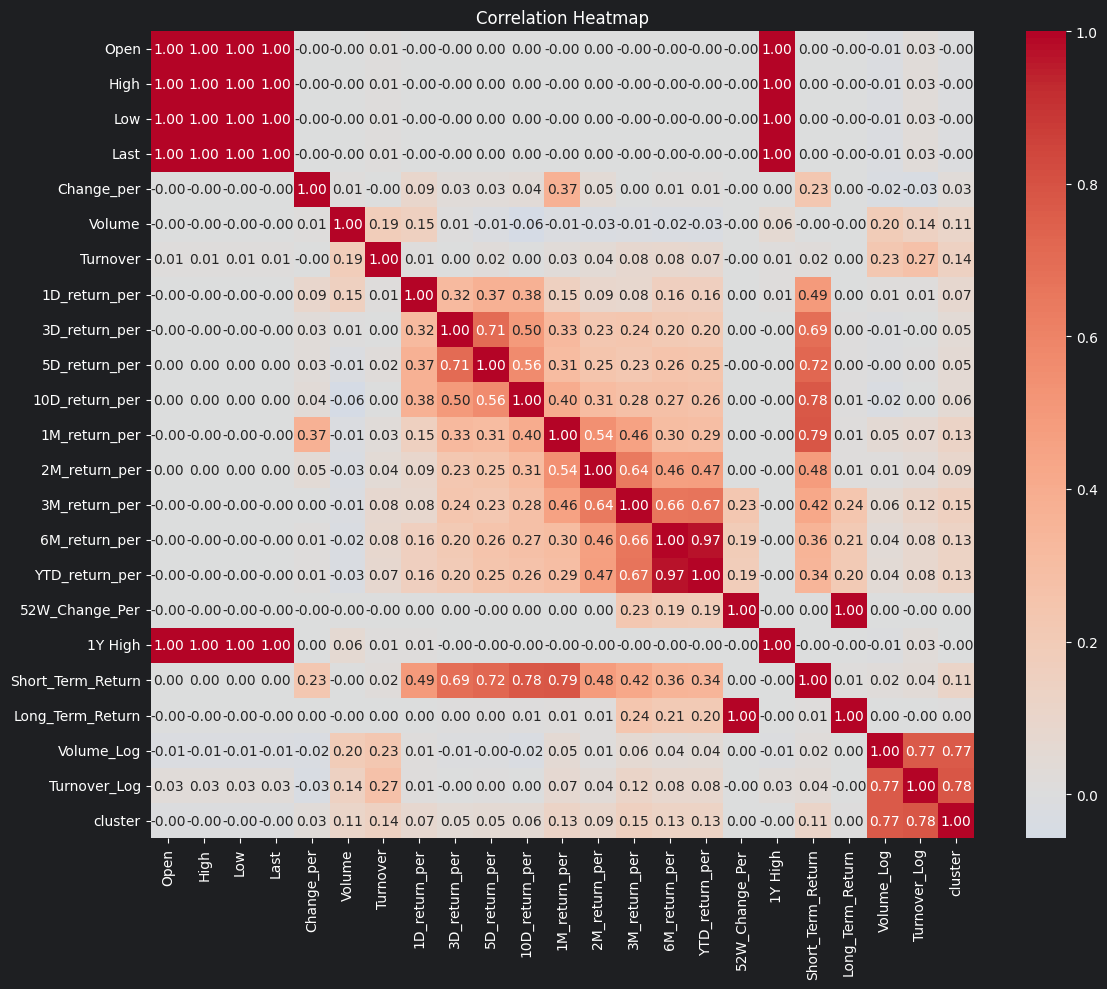

In [34]:
import seaborn as sns

corr=ds.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

> **Findings:** No strong correlations were found between price/volume features and return columns.  
> Return columns (1D through YTD) show expected gradual correlation with each other, shorter periods correlate more with nearby periods and less with longer ones.


---

#### Box Plot Visualization
The box plot will be helpfully to identify the distribution of the data and observing outliers.

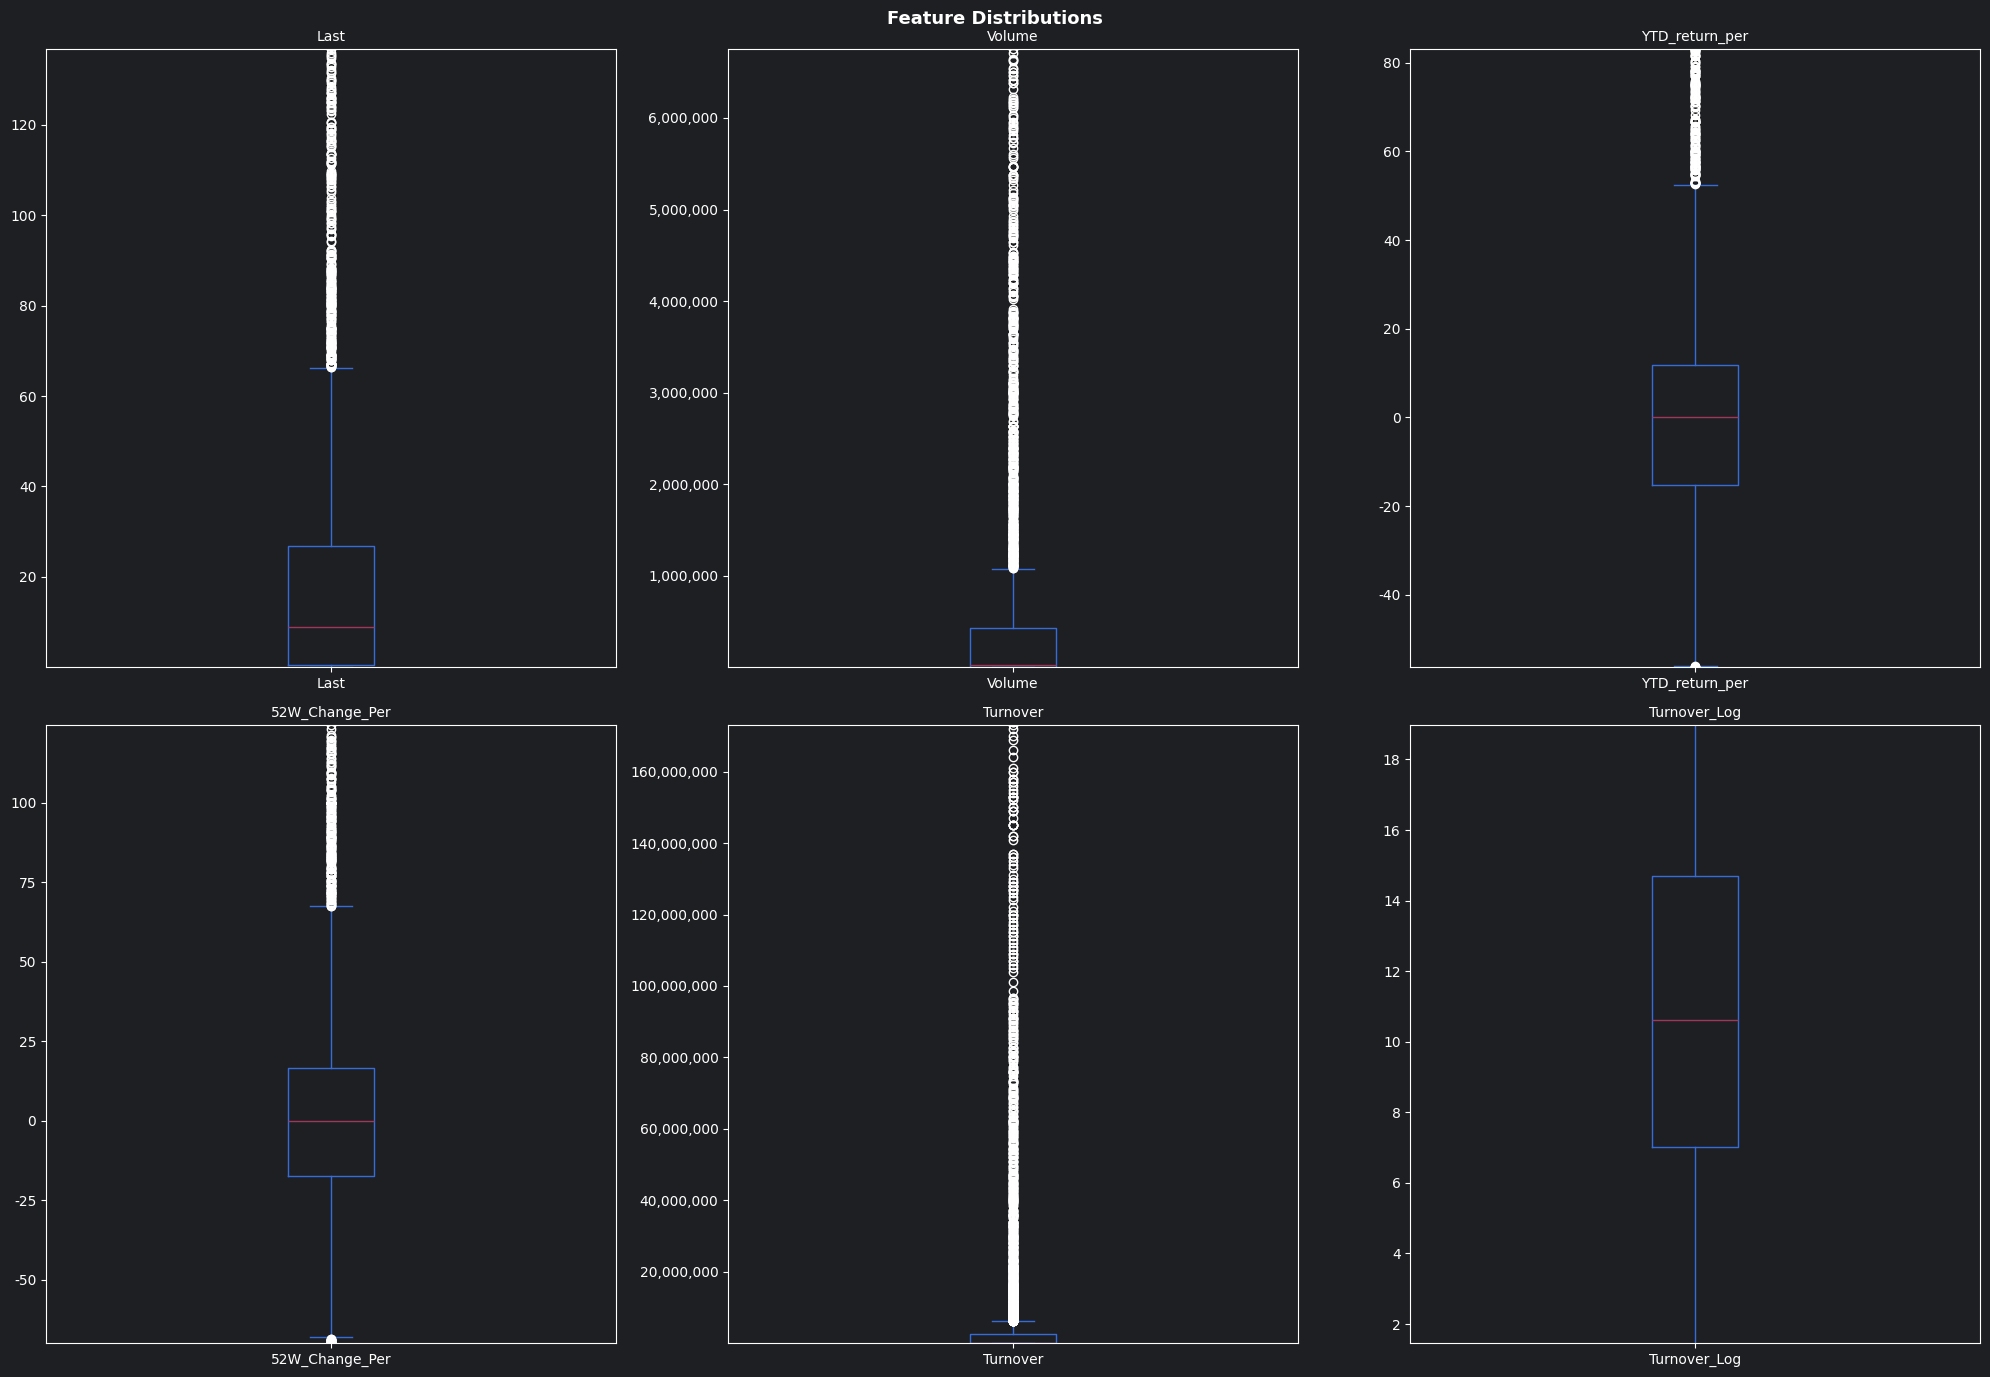

In [57]:
cols = ['Last', 'Volume', 'YTD_return_per', '52W_Change_Per','Turnover','Turnover_Log']

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()
for ax, col in zip(axes, cols):
    ds[col].plot.box(ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_ylim(ds[col].quantile(0.05), ds[col].quantile(0.95))  #Because the data was highly skewed in order to see box we had to fix the axis
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Feature Distributions', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

>**Findings:** The feature distributions reveal a highly skewed dataset with numerous outliers, indicating substantial variation in stock prices, trading activity, and performance metrics across the market which is normal for Stocks datasets. Most stocks are concentrated within lower value ranges, while a small number of stocks exhibiting exceptionally large values. To reduce the impact of these large stocks, a logarithmic transformation was applied to the Turnover feature, resulting in a more balanced distribution that is better suited for analysis and modeling.

---

#### Liquidity Tier Distribution
Visualizing how stocks are spread across liquidity tiers based on daily trading Volume.


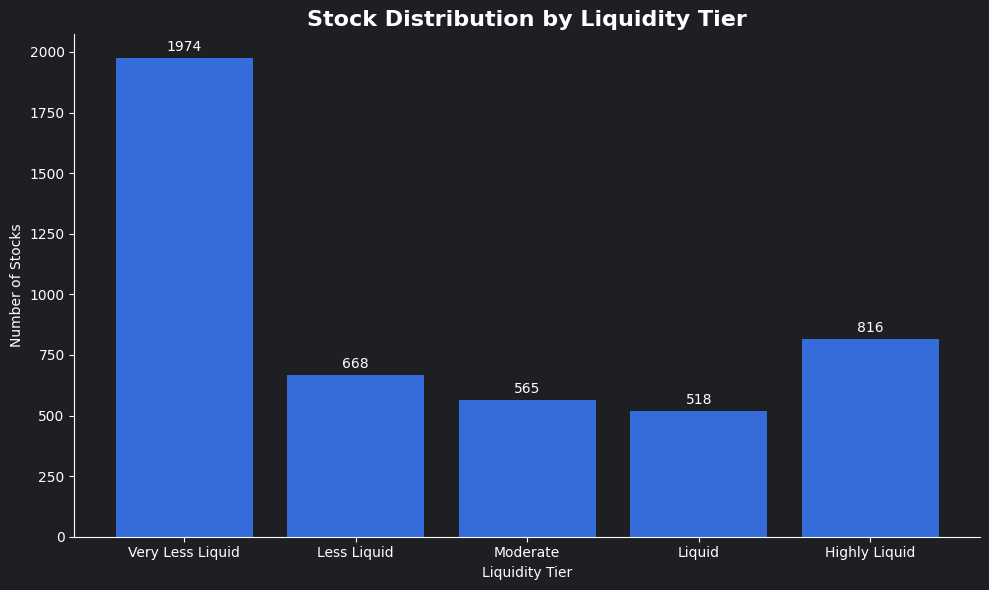

In [99]:
import matplotlib.pyplot as plt

liquidity_counts = (ds['Liquidity_Tier'].value_counts().reindex([
    'Very Less Liquid',
    'Less Liquid',
    'Moderate',
    'Liquid',
    'Highly Liquid'
])
)

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(
    liquidity_counts.index,
    liquidity_counts.values
)

ax.set_title(
    'Stock Distribution by Liquidity Tier',
    fontsize=16,
    weight='bold'
)

ax.set_xlabel('Liquidity Tier')
ax.set_ylabel('Number of Stocks')

ax.bar_label(
    bars,
    padding=3,
    fontsize=10
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

> **Findings:** The vast majority of stocks fall into the **Very Less Liquid** tier (Volume < 10K), suggesting the U.S. stock sample in this dataset is dominated by highly liquid small-cap and micro-cap stocks.
> This is expected since large actively-traded names are a small fraction of all listed securities.


---

#### Liquidity Tier and Average Stock price Distribution

This charts show the average stock price for each liquidity tier.

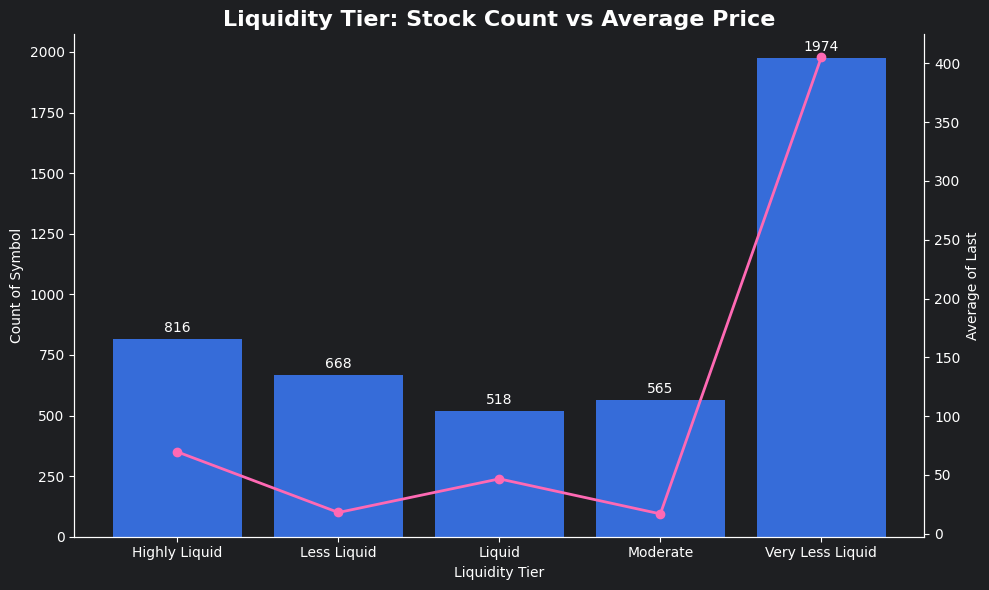

In [100]:
import matplotlib.pyplot as plt

pivot = (ds.groupby('Liquidity_Tier', observed=False).agg(
          Count_of_Symbol=('Symbol', 'count'),
          Average_of_Last=('Last', 'mean')
).reindex([
    'Highly Liquid',
    'Less Liquid',
    'Liquid',
    'Moderate',
    'Very Less Liquid'
])
)

fig, ax1 = plt.subplots(figsize=(10,6))

# Bars (Count of Symbol)
bars = ax1.bar(
    pivot.index,
    pivot['Count_of_Symbol']
)

ax1.set_ylabel('Count of Symbol')
ax1.set_xlabel('Liquidity Tier')

# Secondary axis for Average Last
ax2 = ax1.twinx()

ax2.plot(
    pivot.index,
    pivot['Average_of_Last'],
    marker='o',
    linewidth=2,
    color='hotpink'
)

ax2.set_ylabel('Average of Last')

# Labels on bars
ax1.bar_label(
    bars,
    padding=3
)

ax1.set_title(
    'Liquidity Tier: Stock Count vs Average Price',
    fontsize=16,
    weight='bold'
)

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

> **Findings:** Stocks with the highest average price tend to be the least liquid — high-priced stocks attract less retail trading activity, explaining the low Volume.  
> Highly Liquid stocks, by contrast, have a much lower average price, consistent with high-volume penny and small-cap trading behavior.


---

#### Total Return Performance Trend Distribution
Showing how many stocks fall into each performance trend category based on how many return periods were positive.


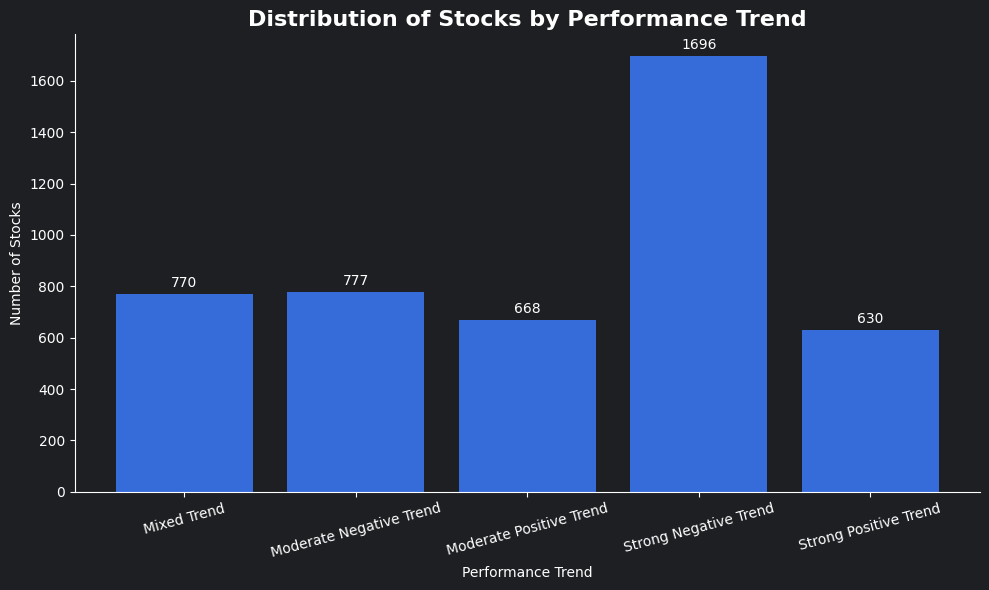

In [103]:
import matplotlib.pyplot as plt

trend_counts = (ds['Total_Return_Performance_Trend'].value_counts().reindex([
    'Mixed Trend',
    'Moderate Negative Trend',
    'Moderate Positive Trend',
    'Strong Negative Trend',
    'Strong Positive Trend'
])
)

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(
    trend_counts.index,
    trend_counts.values
)

ax.set_title(
    'Distribution of Stocks by Performance Trend',
    fontsize=16,
    weight='bold'
)

ax.set_xlabel('Performance Trend')
ax.set_ylabel('Number of Stocks')

ax.bar_label(
    bars,
    padding=3,
    fontsize=10
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

> **Findings:** The majority of stocks fall into the **Strong Negative Trend** category, meaning most stocks in this dataset had negative returns across most time periods.  
> This reflects the broad composition of the market most listed underperforming stocks.


---

#### Short-Term Return and Price Tier Distribution
Side-by-side comparison of how stocks are distributed across short-term return segments and price tiers.


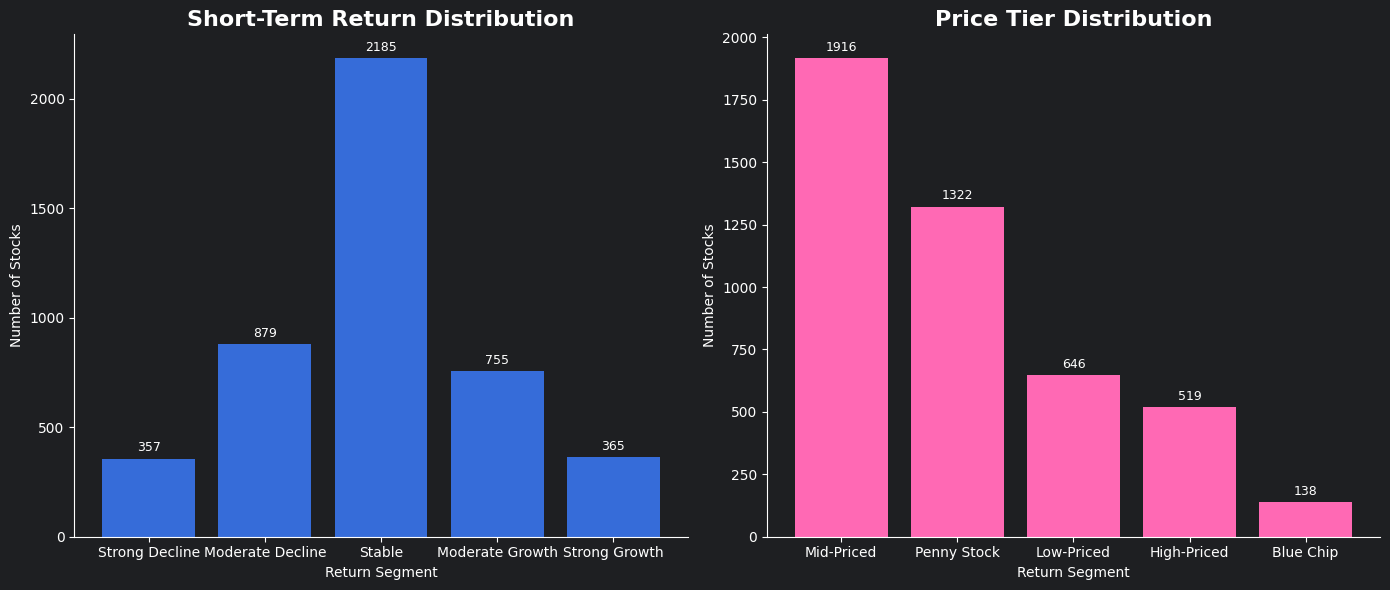

In [104]:
import matplotlib.pyplot as plt

short_counts = (ds['Short_Term_Segment'].value_counts().reindex([
    'Strong Decline',
    'Moderate Decline',
    'Stable',
    'Moderate Growth',
    'Strong Growth'
])
)

long_counts = (ds['Price_Tier'].value_counts())

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14,6)
)

bars1 = ax1.bar(
    short_counts.index,
    short_counts.values
)

ax1.set_title(
    'Short-Term Return Distribution',
    fontsize=16,
    weight='bold'
)

ax1.set_xlabel('Return Segment')
ax1.set_ylabel('Number of Stocks')

ax1.bar_label(
    bars1,
    padding=3,
    fontsize=9
)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

bars2 = ax2.bar(
    long_counts.index,
    long_counts.values
    ,color='hotpink'
)

ax2.set_title(
    'Price Tier Distribution',
    fontsize=16,
    weight='bold'
)

ax2.set_xlabel('Return Segment')
ax2.set_ylabel('Number of Stocks')

ax2.bar_label(
    bars2,
    padding=3,
    fontsize=9
)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

> **Finding 1:** Short-term returns are heavily concentrated in the **Stable** segment (~2,185 stocks), meaning most stocks showed minimal price movement in the term which is typical behavior for dormant securities.
>
> **Finding 2:** The market is dominated by **Mid-Priced** (5–50) and **Penny Stocks** (< 1), with Blue-Chip stocks (> 200) making up only a small fraction of the total dataset.


---

<h2
style = "font-family: 'Courier New';" >
Model Building & Evaluation
</h2>

This section covers model selection, data preparation, pipeline setup, and training the clustering model.  
- **Task 3.1** - Select a model, prepare the training dataset, build the preprocessing pipeline, and fit the model
- **Task 3.2** - Evaluate clustering results and compare cluster assignments against our manual segmentations


<h4>
Task 3.1 - Choose and build a Model
</h4>

#### Choosing the Model
The data has no labeled target variable, is mostly numerical, highly skewed, and has no time-series structure — making it well suited for **unsupervised clustering**.  
**KMeans** was selected because it works well with scaled numeric data, is computationally efficient at this dataset size (~4,500 rows), and its cluster count (`k=6`) aligns naturally with our segmentation rubrics.


#### Data Preparation
We create a training dataset by dropping non-numeric and derived columns (segmentation labels, log columns, identifiers) to keep only the raw numeric features for clustering.  
This ensures the model learns from the actual price and return cluster based on values rather than our manually created categories.


In [112]:
ds.columns

Index(['Symbol', 'Name', 'Open', 'High', 'Low', 'Last', 'Change_per', 'Volume',
       'Turnover', 'Date', '1D_return_per', '3D_return_per', '5D_return_per',
       '10D_return_per', '1M_return_per', '2M_return_per', '3M_return_per',
       '6M_return_per', 'YTD_return_per', '52W_Change_Per', '1Y High',
       '1Y Low', 'Liquidity_Tier', 'Performance_Trend', '52W_Performance',
       'Short_Term_Return', 'Short_Term_Segment', 'Long_Term_Return',
       'Long_Term_Segment', 'Volume_Log', 'Turnover_Log', 'Price_Tier',
       'Total_Return_Performance_Trend'],
      dtype='str')

In [116]:
# we will use "drop()" function to keep only required columns and drop the remaining

ds_train=ds.drop(['Symbol', 'Name','Liquidity_Tier', 'Total_Return_Performance_Trend', '52W_Performance','Short_Term_Return', 'Short_Term_Segment', 'Long_Term_Return','Long_Term_Segment', 'Volume_Log', 'Turnover_Log', 'Price_Tier','Date'],axis=1)


#### Analyzing Data Distribution
Before applying scaling, we check how skewed the numeric columns are and highly skewed features need log transformation to prevent them from dominating the calculations in KMeans.


In [117]:
# Now we will identify skewed columns and look at the data distribution

pd.set_option('display.float_format', '{:,.2f}'.format)

ds_train.skew()


Open             67.37
High             67.37
Low              67.37
Last             67.37
Change_per       65.29
Volume           48.62
Turnover         17.37
1D_return_per    17.55
3D_return_per    11.17
5D_return_per     8.64
10D_return_per   14.34
1M_return_per    10.99
2M_return_per     9.72
3M_return_per     6.71
6M_return_per     6.15
YTD_return_per    6.35
52W_Change_Per   67.32
1Y High          66.91
1Y Low            0.00
dtype: float64

In [10]:
ds['Volume'].describe(percentiles=[0.5,0.9,0.95,0.99,0.999])

count           4,541.00
mean        1,868,609.19
std        18,179,205.19
min                 1.00
50%            20,700.00
90%         3,000,000.00
95%         6,750,000.00
99%        31,500,000.00
99.9%     122,760,000.00
max     1,090,000,000.00
Name: Volume, dtype: float64

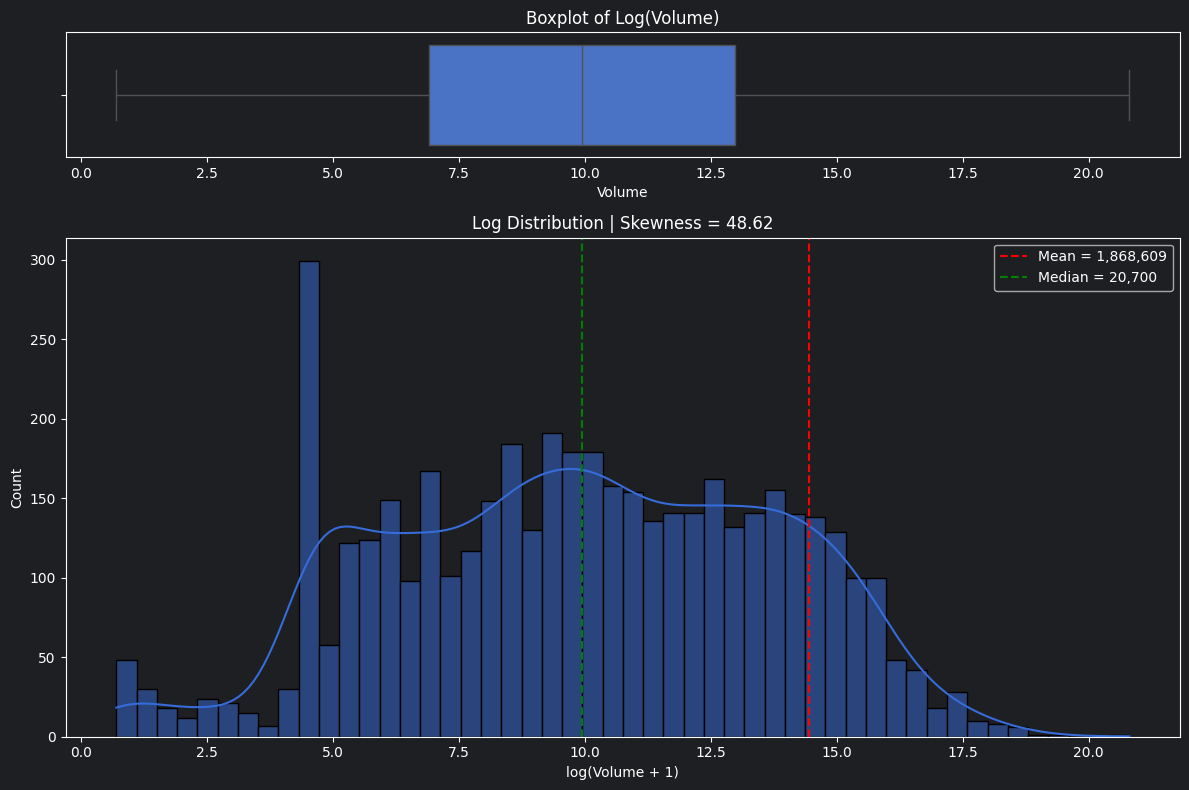

In [11]:

x = ds_train['Volume'].dropna()

fig, ax = plt.subplots(
    2, 1,
    figsize=(12, 8),
    gridspec_kw={'height_ratios': [1, 4]}
)

# Boxplot
sns.boxplot(x=np.log1p(x), ax=ax[0])

# Histogram
sns.histplot(
    np.log1p(x),
    bins=50,
    kde=True,
    ax=ax[1]
)

ax[1].axvline(
    np.log1p(x.mean()),
    color='red',
    linestyle='--',
    label=f'Mean = {x.mean():,.0f}'
)

ax[1].axvline(
    np.log1p(x.median()),
    color='green',
    linestyle='--',
    label=f'Median = {x.median():,.0f}'
)

ax[0].set_title('Boxplot of Log(Volume)')
ax[1].set_title(f'Log Distribution | Skewness = {x.skew():.2f}')
ax[1].set_xlabel('log(Volume + 1)')
ax[1].legend()

plt.tight_layout()
plt.show()

>**Skewness Findings:**
>- `Volume` (48.62) and `Turnover` (17.37) are extremely right-skewed due to the massive difference in trading activity between small and large-cap >stocks — these will be treated with `log1p` followed by `StandardScaler`
>- Return columns (`1D_return_per` through `52W_Change_Per`) and price columns (`Open`, `High`, `Low`, `Last`) show high skewness and also contain negative values, which makes `log1p` unsafe to apply on them

#### Preprocessing Pipeline
We use `sklearn.Pipeline` combined with `ColumnTransformer` to apply log transformation and standard scaling to all numeric columns.

**Functions used:**

- `StandardScaler` uses mean and standard deviation, which get pulled heavily by extreme outliers like crashed stocks (-90%) and high flyers (+500%) in our data would distort the scaling for every other stock.
- `Log1p()` was used instead of normal log as it allows values to stay **>0** by adding `+1`


In [24]:
# Here we used `Pipeline()` to create a pipeline that apply log and scaling transformations and then use `ColumnTransformer` to apply them on all numerical column

log_cols = ['Volume', 'Turnover']
cols = ds_train.drop(log_cols,axis=1).columns

log_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

pipeline = ColumnTransformer([
    ('log_scale', log_pipeline, log_cols),
    ('Standard_scale', StandardScaler(), cols)
])


#### Identifying Optimal No. of Clusters using Elbow Method

We will use Elbow meathod to find out optimal number of clusteres we should use to create most optimal clusters

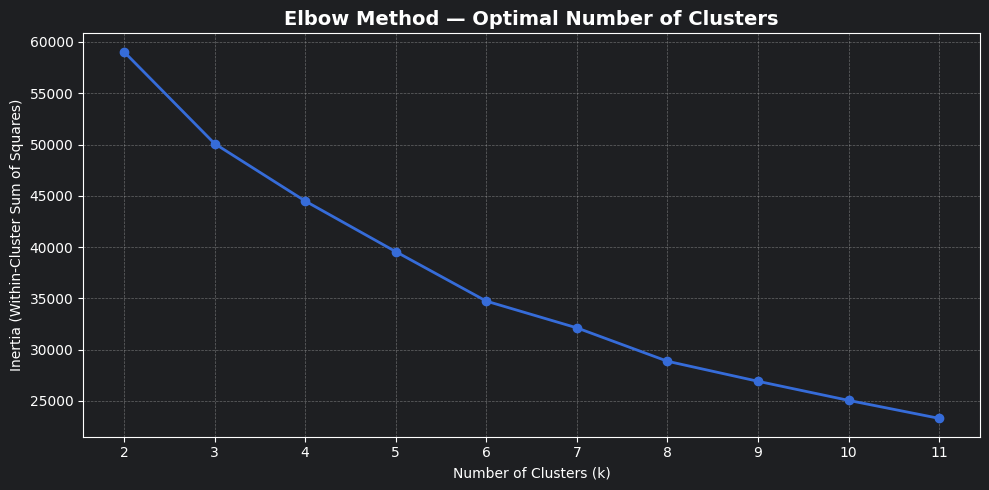

In [36]:

inertia = []
k_range = range(2, 12)

for k in k_range:
    km = Pipeline([
        ('Preprocess', pipeline),
        ('Model', KMeans(n_clusters=k, n_init=10, random_state=42))
    ])
    km.fit(ds_train)
    inertia.append(km.named_steps['Model'].inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', linewidth=2)
plt.title('Elbow Method - Optimal Number of Clusters', fontsize=14, weight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

> **Findings:** After using the Elbow method we found out that after Cluster `5` and `6` the inertia drastically start to decrease so in order to get the most optimal clustering we will use 5-6 clusters

#### Configuring and Training the model

In [82]:
Model=Pipeline([
    ('Preprocess',pipeline),
    ('Model',KMeans(n_clusters=6,n_init=1000,random_state=32))
])

In [83]:
Model.fit(ds_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Preprocess', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_scale', ...), ('robust_scale', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

#### Evaluating the Result

In [84]:
clusters=Model.named_steps['Model'].labels_
ds['cluster']=clusters

In [85]:
ds.sort_values('cluster')

,Symbol,Name,Open,High,Low,Last,Change_per,Volume,Turnover,Date,...,Short_Term_Return,Short_Term_Segment,Long_Term_Return,Long_Term_Segment,Volume_Log,Turnover_Log,Price_Tier,Total_Return_Performance_Trend,cluster,cluster_label
4499,EDVR.US,ENDEAVOR BANCORP,19.250,19.250,19.2500,19.250,0.00,1100.0,2.117500e+04,Jun 18,...,3.214,Moderate Growth,16.128,Moderate Growth,7.003974,9.960624,Mid-Priced,Moderate Positive Trend,0,Dormant Small-Cap Stocks
2601,CBRJ.US,CARBON RACE,0.000,0.000,0.0000,0.000,0.00,926.0,0.000000e+00,Jun 18,...,0.000,Stable,0.000,Stable,6.831954,0.000000,Penny Stock,Strong Negative Trend,0,Dormant Small-Cap Stocks
2603,CBRRF.US,CHAIN BRIDGE I,12.080,12.080,12.0800,12.080,0.00,1.0,1.208000e+01,Jun 18,...,0.000,Stable,0.000,Stable,0.693147,2.571084,Mid-Priced,Strong Negative Trend,0,Dormant Small-Cap Stocks
2606,CBSC.US,CB SCIENTIFIC,0.035,0.035,0.0350,0.035,0.00,4000.0,1.400000e+02,Jun 18,...,-4.280,Moderate Decline,-12.500,Moderate Decline,8.294300,4.948760,Penny Stock,Strong Negative Trend,0,Dormant Small-Cap Stocks
2608,CBSU.US,CENTRAL BANK,30.000,30.000,30.0000,30.000,0.00,1.0,3.000000e+01,Jun 18,...,15.820,Strong Growth,79.100,Strong Growth,0.693147,3.433987,Mid-Priced,Mixed Trend,0,Dormant Small-Cap Stocks
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24,AAON.US,AAON INC,138.350,139.450,134.2900,136.720,2.52,1320000.0,1.310000e+08,Jun 18,...,2.044,Moderate Growth,73.354,Strong Growth,14.093143,18.690708,High-Priced,Strong Positive Trend,4,Active Mid-Cap Stocks
2587,CBL.US,CBL & ASSOCIATES PROPERTIES INC,47.720,48.140,47.1600,47.400,0.34,395000.0,1.350000e+07,Jun 18,...,-0.564,Stable,34.084,Moderate Growth,12.886644,16.418200,Mid-Priced,Moderate Positive Trend,4,Active Mid-Cap Stocks
2589,CBLL.US,CERIBELL INC,17.630,18.080,17.4519,18.030,4.34,709000.0,8.580000e+06,Jun 18,...,1.116,Stable,-10.252,Moderate Decline,13.471612,15.964945,Mid-Priced,Moderate Negative Trend,4,Active Mid-Cap Stocks
49,ABAT.US,AMERICAN BATTERY TECHNOLOGY CO,3.170,3.170,3.0200,3.120,0.65,4830000.0,8.750000e+06,Jun 18,...,-5.386,Moderate Decline,20.044,Moderate Growth,15.390357,15.984564,Low-Priced,Moderate Negative Trend,4,Active Mid-Cap Stocks


**Silhouette Score**

In [86]:

X_transformed = Model.named_steps['Preprocess'].transform(ds_train)
labels = Model.named_steps['Model'].labels_

sil = silhouette_score(X_transformed, labels)
db = davies_bouldin_score(X_transformed, labels)
ch = calinski_harabasz_score(X_transformed, labels)

print(f"Silhouette Score      : {sil:.4f}   (higher is better, range -1 to 1)")
print(f"Davies-Bouldin Score  : {db:.4f}   (lower is better)")
print(f"Calinski-Harabasz     : {ch:.2f}  (higher is better)")

Silhouette Score      : 0.2749   (higher is better, range -1 to 1)
Davies-Bouldin Score  : 0.7263   (lower is better)
Calinski-Harabasz     : 1228.02  (higher is better)


**Scores Evaluations**

The model shows solid clustering performance for financial market data, where perfect separation is rarely achievable due to the continuous and overlapping nature of stock behavior.

- **Silhouette Score: 0.2749** Indicates moderate but real cluster structure. Scores above 0.2 confirm the clusters are meaningful and not random. Overlap between clusters is expected since stocks naturally overlaps rather than being in perfectly distinct groups.
- **Davies-Bouldin Score: 0.7263** A score below 1.0 is considered good, meaning clusters are well-separated relative to their internal spread. Our score of 0.73 confirms the clusters are reasonably compact and distinct from each other.
- **Calinski-Harabasz Score: 1228.02** A high score indicates dense, well-defined clusters. 1228 on a approx 4,500 stock dataset is a strong result, showing the model found clear structure in the data.

> Overall, the evaluation confirms the clustering is working well. The moderate ( average ) Silhouette score is not a issue as it reflects the real-world stock market data, where no hard boundaries exist between groups.

**Heat Map**

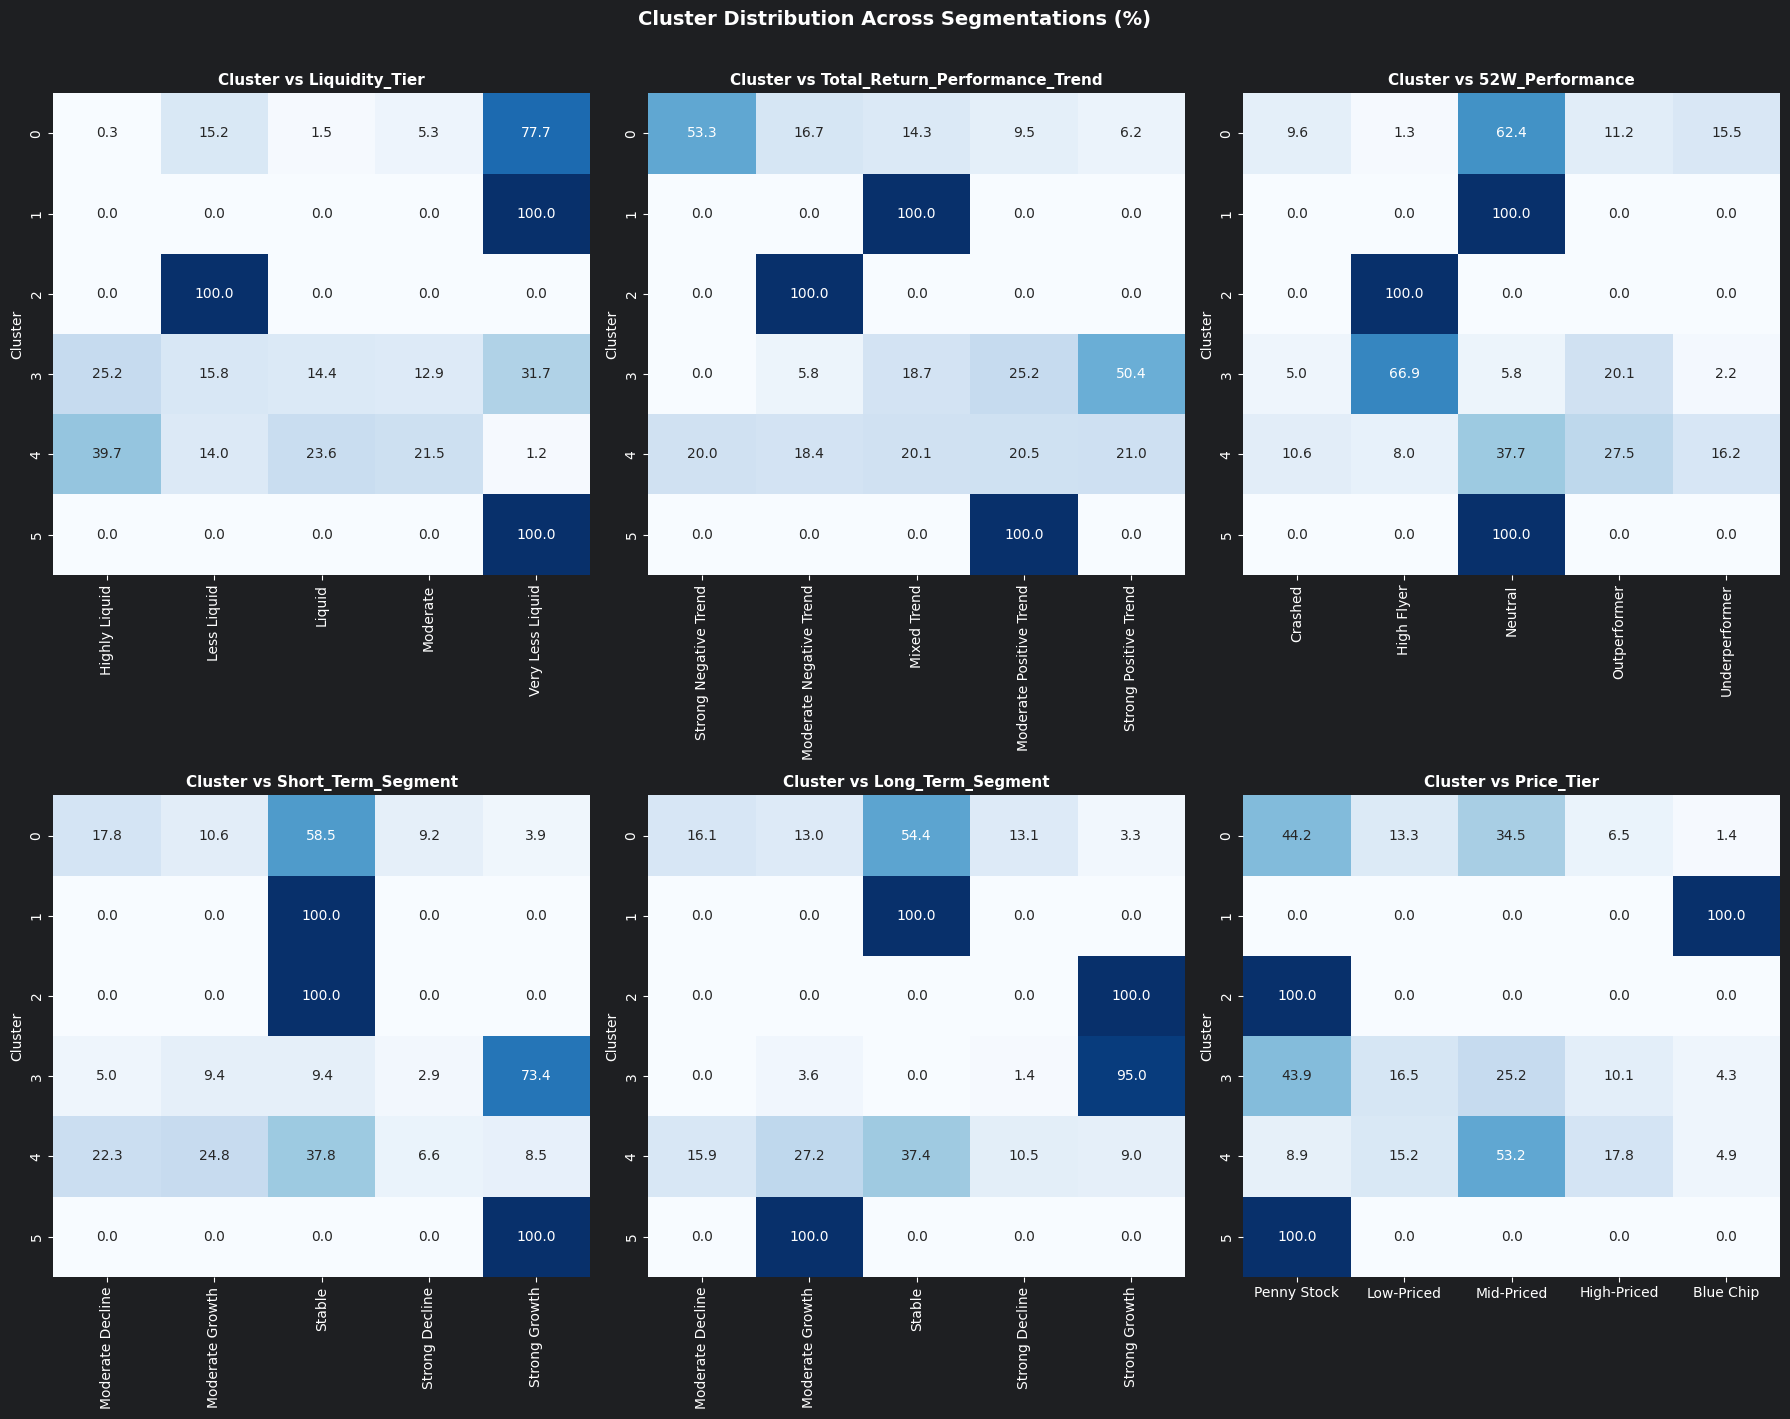

In [62]:

seg_cols = ['Liquidity_Tier', 'Total_Return_Performance_Trend',
            '52W_Performance', 'Short_Term_Segment',
            'Long_Term_Segment', 'Price_Tier']

fig, axes = plt.subplots(2, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(seg_cols):
    ct = pd.crosstab(ds['cluster'], ds[col], normalize='index') * 100
    sns.heatmap(
        ct,
        annot=True,
        fmt='.1f',
        cmap='Blues',
        ax=axes[i],
        cbar=False
    )
    axes[i].set_title(f'Cluster vs {col}', fontsize=11, weight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cluster')

plt.suptitle('Cluster Distribution Across Segmentations (%)', fontsize=14, weight='bold', y=1.01)
plt.tight_layout()
plt.show()

>After carefully examining all the cluster we found out that the clustering happen really well and clusters consisted of just one category from each segmentation in majority. Further we labeled each cluster according to the clustering as follow:


**cluster labels:**
-  0: Dormant Small-Cap Stocks
-  1: Ultra High-Price Outlier
-  2: Extreme Historic Gain Outlier
-  3: High Momentum Growth Stocks
-  4: Active Mid-Cap Mainstream Stocks
-  5: Sub-Penny Anomaly


In [32]:
ds['cluster_label']=ds['cluster'].map({
    0: 'Dormant Small-Cap Stocks',
    1: 'Ultra High-Price Stocks',
    2: 'Extreme Historic Positive',
    3: 'High Momentum Growth Stocks',
    4: 'Active Mid-Cap Stocks',
    5: 'Sub-Penny Anomaly'
})

>**Anomaly:** after clustering we found a major anomaly stock in Cluster 1,2 and 5 which consist of single entry.


#### Saving Final Dataset

In [59]:
ds.to_csv("Final_Clustered_Dataset_US_Stocks_1.csv",index=False)

---